In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import random

In [3]:
def conseguir_diff_centrada(data):

    val_prev = data.shift(1).fillna(data.shift(2))
    val_sig = data.shift(-1).fillna(data.shift(-2))

    diff_prev = abs(val_prev - data)
    diff_sig = abs(val_sig - data)

    diff_centrada = np.minimum(diff_prev, diff_sig)

    return diff_centrada

In [4]:
df = pd.read_csv('../df_procesados/df_planta_1.csv')
df['date_time'] = pd.to_datetime(df['date_time'])

In [5]:
df.columns

Index(['date_time', 'Conductividad DAF',
       'Flujo Parshall 01 entrada a Ecualizador 1', 'Flujo de envío a DAF',
       'Nivel Ecualizador 1 (Tk 30m3)', 'Nivel Ecualizador 2 (Tk 250m3)',
       'Temperatura DAF', 'pH Clarificado DAF (Tk 80m3)',
       'pH Ecualizador 2 (Tk 250m3)', 'pH coagulación entrada DAF',
       'pH entrada a Ecualizador 2 (Tk 250m3)', 'pH salida a Parshall 02',
       'Nivel Clarificado DAF (Tk 80m3)', 'pH entrada a Ecualizador 1',
       'Turbidez salida DAF', 'pH salida y control Ecualizador 1',
       'planta1_activa'],
      dtype='object')

In [6]:
df.columns[9]

'pH coagulación entrada DAF'

In [7]:
columna = df.columns[9]

serie = df.set_index('date_time')[columna]

fecha_inicio = '2025-06-01'
fecha_final = '2025-08-09'

serie = serie[fecha_inicio:fecha_final]

rango_de_dias = pd.date_range(start=fecha_inicio, end=fecha_final, freq='D')

null_th = 0.5
diff_total = conseguir_diff_centrada(serie)
diff = serie.diff()
std_total = diff_total.std()
std_th = 12

labels = []

for dias in rango_de_dias:
    fecha_str = dias.strftime('%Y-%m-%d')

    serie_dia = serie[fecha_str]
    n = len(serie_dia)

    l = ["No hay data suf"] * n

    if serie_dia.isnull().sum() >= n * null_th:
        labels.extend(l)
        continue

    diff_centrada = diff_total[fecha_str]
    diff_dia = diff[fecha_str]

    std = diff_centrada.std()
    if std > std_total:
        std_us = std
    else:
        std_us = std_total

    for i in range(len(diff_centrada)):
        dato = diff_centrada.iloc[i]
        dato_diff = diff_dia.iloc[i]
        if np.isnan(dato):
            l[i] = np.nan
        elif dato >= std_us * std_th or dato_diff >= 4:
            l[i] = "Outlier"
        else:
            l[i] = "Normal"

    labels.extend(l)
    

In [8]:
resultados_df = pd.DataFrame({'Datos': serie, 'Etiqueta': labels, 'Diff_centrada': diff_total})

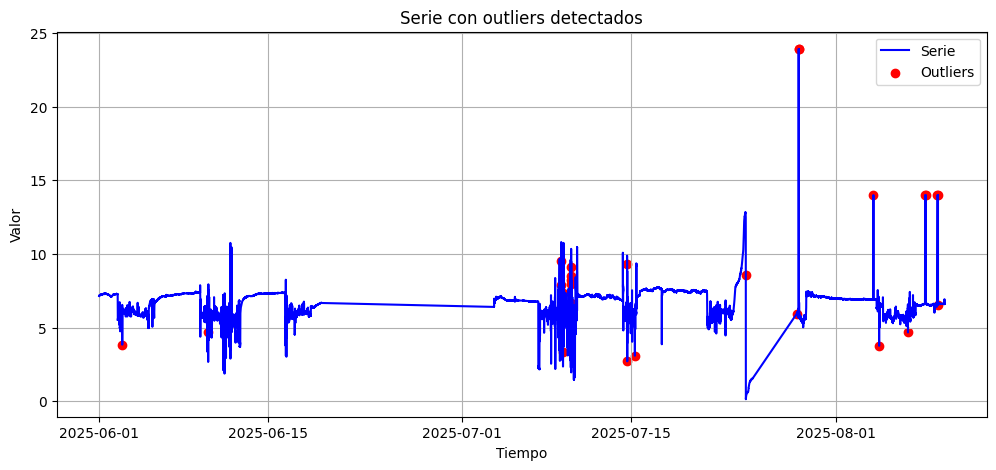

In [9]:
plt.figure(figsize=(12,5))
plt.plot(resultados_df.index, resultados_df["Datos"], label="Serie", color="blue")

# marcar outliers
mask_out = resultados_df["Etiqueta"] == "Outlier"
plt.scatter(
    resultados_df.index[mask_out],
    resultados_df["Datos"][mask_out],
    color="red", marker="o", label="Outliers"
)

plt.title("Serie con outliers detectados")
plt.xlabel("Tiempo")
plt.ylabel("Valor")
plt.legend()
plt.grid(True)
plt.show()

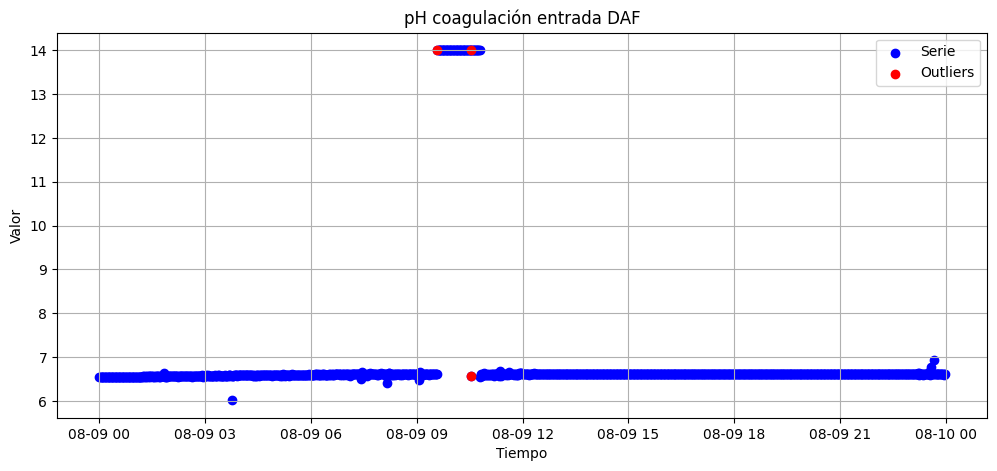

In [15]:
resultados_dia = resultados_df.loc["2025-08-9"]

plt.figure(figsize=(12,5))
plt.scatter(resultados_dia.index, resultados_dia["Datos"], label="Serie", color="blue")

# marcar outliers
mask_out = resultados_dia["Etiqueta"] == "Outlier"
plt.scatter(
    resultados_dia.index[mask_out],
    resultados_dia["Datos"][mask_out],
    color="red", marker="o", label="Outliers"
)

plt.title(columna)
plt.xlabel("Tiempo")
plt.ylabel("Valor")
plt.legend()
plt.grid(True)
plt.show()

In [16]:
len(resultados_dia[resultados_dia["Datos"] == 14])

59